In [2]:
import os

import pandas as pd
import numpy as np
import itertools
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"

path_to_scenarios = '/Users/Guille/Desktop/india_power/scenarios'
path_to_images    = '/Users/Guille/Desktop/india_power/images'
path_to_tables    = '/Users/Guille/Desktop/india_power/tables'
path_to_csvs      = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_inputs    = '/Users/Guille/Desktop/india_power/input_data'

# Results

## Costs, emissions, and clean energy shares

### In the near-term (2030)

In [404]:
df_ = pd.read_csv(path_to_tables + '/pier-clean_energy.csv')
print(df_['scenario'].unique())

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid') 
          & (df_['period'] == 2030)
          & (df_['technology'] == 'clean'))

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid')
          & (df_['period'] == 2030)
          & (df_['technology'] == 'no_clean'))
# print(df_.loc[idx_1_])
# print(df_.loc[idx_2_])

print(df_.loc[idx_1_, 'power_mw'].to_numpy()[0]/( df_.loc[idx_1_, 'power_mw'].to_numpy()[0]+ df_.loc[idx_2_, 'power_mw'].to_numpy()[0]))

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid') 
          & (df_['period'] == 2030)
          & (df_['technology'] == 'clean'))

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid')
          & (df_['period'] == 2030)
          & (df_['technology'] == 'no_clean'))
# print(df_.loc[idx_1_])
# print(df_.loc[idx_2_])

print(df_.loc[idx_1_, 'power_mw'].to_numpy()[0]/( df_.loc[idx_1_, 'power_mw'].to_numpy()[0]+ df_.loc[idx_2_, 'power_mw'].to_numpy()[0]))

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
0.6888850431105996
0.4528016852942397


In [407]:
df_ = pd.read_csv(path_to_tables + '/pier-system_cost.csv')

df_['system_cost'] = df_['variable_cost'] + df_['fixed_cost'] + 5.9e9
idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid') 
          & (df_['period'] == 2030))
print(df_.loc[idx_1_])

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
          & (df_['period'] == 2030))
print(df_.loc[idx_2_])

print(1. - df_.loc[idx_1_, 'system_cost'].to_numpy()[0]/df_.loc[idx_2_, 'system_cost'].to_numpy()[0])

   period                                           scenario load_zone  \
1    2030  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid       all   

   variable_cost    fixed_cost   system_cost  
1   2.456985e+10  9.756039e+10  1.280302e+11  
    period                                           scenario load_zone  \
13    2030  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...       all   

    variable_cost    fixed_cost   system_cost  
13   4.677061e+10  8.471879e+10  1.373894e+11  
0.06812142567255086


In [336]:
df_ = pd.read_csv(path_to_tables + '/pier-emissions.csv')
print(df_['scenario'].unique())

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid') 
          & (df_['period'] == 2020))
idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid')
          & (df_['period'] == 2030))
# print(df_.loc[idx_1_])
# print(df_.loc[idx_2_])

print(df_.loc[idx_2_, 'carbon_emissions_tons'].to_numpy()[0]/df_.loc[idx_1_, 'carbon_emissions_tons'].to_numpy()[0])

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid') 
          & (df_['period'] == 2020))
idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid')
          & (df_['period'] == 2030))
# print(df_.loc[idx_1_])
# print(df_.loc[idx_2_])

print(df_.loc[idx_2_, 'carbon_emissions_tons'].to_numpy()[0]/df_.loc[idx_1_, 'carbon_emissions_tons'].to_numpy()[0])

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
0.6035177647178793
1.1275201252528861


### In the medium term (2040)

In [350]:
df_ = pd.read_csv(path_to_tables + '/pier-emissions.csv')
print(df_['scenario'].unique())

df_['intensity'] = df_['carbon_emissions_tons']/df_['load_mw']

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid') 
          & (df_['period'] == 2020))

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid')
          & (df_['period'] == 2040))
# print(df_.loc[idx_1_])
# print(df_.loc[idx_2_])

print(df_.loc[idx_1_, 'intensity'].to_numpy()[0], df_.loc[idx_2_, 'intensity'].to_numpy()[0])
print(df_.loc[idx_1_, 'intensity'].to_numpy()[0] - df_.loc[idx_2_, 'intensity'].to_numpy()[0])
print(1. - df_.loc[idx_2_, 'intensity'].to_numpy()[0]/df_.loc[idx_1_, 'intensity'].to_numpy()[0])

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
0.7288078360490977 0.21257079491309525
0.5162370411360024
0.7083308049136083


In [408]:
df_1_ = pd.read_csv(path_to_tables + '/pier-system_cost.csv')
df_2_ = pd.read_csv(path_to_tables + '/pier-emissions.csv')
df_   = pd.merge(df_1_, df_2_, on=['period', 'scenario'], how='inner')

df_['levelized'] = (df_['variable_cost'] + df_['fixed_cost'] + 5.9e9)/df_['load_mw']

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid') 
          & (df_['period'] == 2020))
print(df_.loc[idx_1_])

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid')
          & (df_['period'] == 2040))
print(df_.loc[idx_2_])

print(df_.loc[idx_1_, 'levelized'].to_numpy()[0], df_.loc[idx_2_, 'levelized'].to_numpy()[0])
print(df_.loc[idx_1_, 'levelized'].to_numpy()[0] - df_.loc[idx_2_, 'levelized'].to_numpy()[0])
print(1. - df_.loc[idx_2_, 'levelized'].to_numpy()[0]/df_.loc[idx_1_, 'levelized'].to_numpy()[0])

   period                                           scenario load_zone_x  \
4    2020  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500G...         all   

   variable_cost    fixed_cost load_zone_y  carbon_emissions_tons  \
4   3.944529e+10  4.207209e+10         all           1.119110e+09   

        load_mw  levelized  
4  1.535536e+09  56.929569  
   period                                           scenario load_zone_x  \
6    2040  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500G...         all   

   variable_cost    fixed_cost load_zone_y  carbon_emissions_tons  \
6   3.435344e+10  1.493140e+11         all           8.904444e+08   

        load_mw  levelized  
6  4.188931e+09  45.254377  
56.92956897594688 45.254377320191864
11.675191655755015
0.20508132883788144


### In the long-term (2050)

In [409]:
df_1_ = pd.read_csv(path_to_tables + '/pier-system_cost.csv')
df_2_ = pd.read_csv(path_to_tables + '/pier-emissions.csv')
df_   = pd.merge(df_1_, df_2_, on=['period', 'scenario'], how='inner')
print(df_['scenario'].unique())

df_['levelized'] = (df_['variable_cost'] + df_['fixed_cost'] + 5.9e9)/df_['load_mw']

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid') 
          & (df_['period'] == 2050))
#print(df_.loc[idx_1_])

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid')
          & (df_['period'] == 2050))
#print(df_.loc[idx_2_])

idx_3_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
          & (df_['period'] == 2050))
#print(df_.loc[idx_3_])

idx_4_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid')
          & (df_['period'] == 2050))
#print(df_.loc[idx_4_])

print(df_.loc[idx_2_, 'levelized'].to_numpy()[0]/df_.loc[idx_1_, 'levelized'].to_numpy()[0] - 1)
print(df_.loc[idx_3_, 'levelized'].to_numpy()[0]/df_.loc[idx_1_, 'levelized'].to_numpy()[0] - 1)
print(df_.loc[idx_4_, 'levelized'].to_numpy()[0]/df_.loc[idx_1_, 'levelized'].to_numpy()[0] - 1)

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
0.07196721301843945
0.10898881195367438
0.21503372031524814


In [365]:
df_ = pd.read_csv(path_to_tables + '/pier-emissions.csv')
print(df_['scenario'].unique())

idx_1_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid') 
          & (df_['period'] == 2020))

idx_2_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid')
          & (df_['period'] == 2050))
# print(df_.loc[idx_1_])
# print(df_.loc[idx_2_])

print(df_.loc[idx_1_, 'carbon_emissions_tons'].to_numpy()[0], df_.loc[idx_2_, 'carbon_emissions_tons'].to_numpy()[0])
print(1. - df_.loc[idx_2_, 'carbon_emissions_tons'].to_numpy()[0]/df_.loc[idx_1_, 'carbon_emissions_tons'].to_numpy()[0])

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
1119110449.3078015 938375704.7215072
0.16149857656863398


### VRE and storage technology costs impact

In [394]:
df_ = pd.read_csv(path_to_tables + '/cost-system_cost.csv')

df_['system_cost']= df_['variable_cost'] + df_['fixed_cost'] + 5.9e9

df_['min_system_cost'] = df_['system_cost']
df_['max_system_cost'] = df_['system_cost']

df_ = df_.groupby(['period']).agg({'min_system_cost': 'min',
                                   'max_system_cost': 'max'}).reset_index(drop = False)

df_['max_inc_system_cost'] = (df_['max_system_cost'] - df_['max_system_cost'].to_numpy()[0])/1e9
df_['min_inc_system_cost'] = (df_['min_system_cost'] - df_['min_system_cost'].to_numpy()[0])/1e9

df_['max_inc_system_cost_cr'] = 72*(df_['max_system_cost'] - df_['max_system_cost'].to_numpy()[0])/1e7
df_['min_inc_system_cost_cr'] = 72*(df_['min_system_cost'] - df_['min_system_cost'].to_numpy()[0])/1e7

df_['max_times_system_cost'] = df_['max_system_cost']/df_['max_system_cost'].to_numpy()[0]
df_['min_times_system_cost'] = df_['min_system_cost']/df_['min_system_cost'].to_numpy()[0]
print(df_)

   period  min_system_cost  max_system_cost  max_inc_system_cost  \
0    2020     8.151739e+10     8.151739e+10             0.000000   
1    2030     1.246794e+11     1.387361e+11            57.218720   
2    2040     1.599743e+11     2.068841e+11           125.366703   
3    2050     2.087623e+11     3.165819e+11           235.064466   

   min_inc_system_cost  max_inc_system_cost_cr  min_inc_system_cost_cr  \
0             0.000000            0.000000e+00                0.000000   
1            43.162040            4.119748e+05           310766.684936   
2            78.456922            9.026403e+05           564889.841075   
3           127.244922            1.692464e+06           916163.437450   

   max_times_system_cost  min_times_system_cost  
0               1.000000               1.000000  
1               1.701920               1.529483  
2               2.537914               1.962456  
3               3.883611               2.560954  


In [403]:
df_1_ = pd.read_csv(path_to_tables + '/cost-system_cost.csv')
df_2_ = pd.read_csv(path_to_tables + '/cost-emissions.csv')
df_   = pd.merge(df_1_, df_2_, on = ['period', 'scenario'], how = 'inner')

df_['system_cost'] = df_['variable_cost'] + df_['fixed_cost'] + 5.9e9
df_['levelized']   = df_['system_cost'] / df_['load_mw']

idx_1_ = df_['period'] == 2020
idx_2_ = df_['period'] == 2050

print(df_.loc[idx_1_])
print(df_.loc[idx_2_])

print(df_.loc[idx_2_, 'levelized'].to_numpy()/df_.loc[idx_1_, 'levelized'].to_numpy())

    period                                           scenario load_zone_x  \
0     2020  VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...         all   
4     2020  VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90C...         all   
8     2020  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...         all   
12    2020  VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90C...         all   
16    2020  VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90...         all   
20    2020  VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_9...         all   

    variable_cost    fixed_cost load_zone_y  carbon_emissions_tons  \
0    3.944529e+10  4.207209e+10         all           1.119110e+09   
4    3.944529e+10  4.207209e+10         all           1.119110e+09   
8    3.944529e+10  4.207209e+10         all           1.119110e+09   
12   3.944529e+10  4.207209e+10         all           1.119110e+09   
16   3.944529e+10  4.207209e+10         all           1.119110e+09   
20   3.944529e+10  4.207209e+10         

### Demand projections

In [161]:
df_ = pd.read_csv(path_to_tables + '/demand-system_cost.csv')
print(df_['scenario'].unique())

period = 2050

df_['system_cost'] = df_['variable_cost'] + df_['fixed_cost'] + 5.9e9

idx_ = ((df_['period'] == period) 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow'))

ICEDlow = df_.loc[idx_, 'system_cost'].to_numpy()[0]

idx_ = ((df_['period'] == period) 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid'))

ICEDmid = df_.loc[idx_, 'system_cost'].to_numpy()[0]

idx_ = ((df_['period'] == period) 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh'))

ICEDhigh = df_.loc[idx_, 'system_cost'].to_numpy()[0]
print(ICEDlow, ICEDmid, ICEDhigh)

idx_ = ((df_['period'] == period) 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERlow'))

PIERlow = df_.loc[idx_, 'system_cost'].to_numpy()[0]

idx_ = ((df_['period'] == period) 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))

PIERmid = df_.loc[idx_, 'system_cost'].to_numpy()[0]

idx_ = ((df_['period'] == period) 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERhigh'))

PIERhigh = df_.loc[idx_, 'system_cost'].to_numpy()[0]
print(PIERlow, PIERmid, PIERhigh)

print(ICEDlow/PIERlow - 1, ICEDmid/PIERmid - 1, ICEDhigh/PIERhigh - 1)

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDlow'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_ICEDhigh'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERlow'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERhigh']
286300929653.05237 301566161107.6485 325666817284.57434
255893170766.38553 273397303042.45633 297627321233.94824
0.11882989606794636 0.10303268449146974 0.09421008775127149


## Cost-optimal capacity deployment and energy generation

### Coal and gas capacity

In [27]:
df_ = pd.read_csv(path_to_inputs + '/india_gen_2019-20.csv')
print(df_)

df_ = df_.groupby(['source']).agg({'generation_gwh': 'sum'})
print(df_)

fossil_fuels_frac = (df_.loc['Coal', 'generation_gwh'] + df_.loc['Oil & Gas', 'generation_gwh'])/df_['generation_gwh'].sum()
print(100*fossil_fuels_frac)

print(df_.loc['Coal', 'generation_gwh'])
print(100*df_.loc['Coal', 'generation_gwh']/df_['generation_gwh'].sum())

              state    FY       source power_mw  generation_gwh
0    Andhra Pradesh  2020         Coal    11590        56916.07
1    Andhra Pradesh  2020    Oil & Gas  4935.34         3013.62
2    Andhra Pradesh  2020        Hydro     1610         3013.43
3    Andhra Pradesh  2020        Solar  3698.32         5855.11
4    Andhra Pradesh  2020         Wind  4092.45         7626.64
..              ...   ...          ...      ...             ...
159     West Bengal  2020        Hydro   1341.2         2916.38
160     West Bengal  2020        Solar   127.24           64.29
161     West Bengal  2020  Small Hydro     98.5          115.68
162     West Bengal  2020    Bio Power   321.09         1295.07
163          Bhutan  2020        Hydro     2326         9186.00

[164 rows x 5 columns]
             generation_gwh
source                     
Bio Power          14107.06
Coal              993879.10
Hydro             164684.84
Nuclear            46472.45
Oil & Gas          48550.87
Small Hydro 

In [25]:
df_ = pd.read_csv(path_to_tables + '/input_data-electricity_system_groups.csv')
print(df_)

df_ = df_.groupby(['technology']).agg({'capacity_mw': 'sum'})
print(df_)

print(df_.loc['Coal', 'capacity_mw'])
print(df_.loc['Coal', 'capacity_mw']/df_['capacity_mw'].sum())

    technology       load_zone  capacity_mw
0         Coal  Andhra_Pradesh    11678.618
1         Coal           Assam      883.310
2         Coal           Bihar     5875.500
3         Coal      Chandigarh       14.400
4         Coal    Chhattisgarh    29179.048
..         ...             ...          ...
129       Wind  Madhya_Pradesh      503.000
130       Wind     Maharashtra     1000.000
131       Wind       Rajasthan      859.000
132       Wind      Tamil_Nadu     1860.000
133       Wind       Telangana       25.000

[134 rows x 3 columns]
                capacity_mw
technology                 
Coal             235403.520
Diesel             1213.960
Gas               24505.359
Hydro             42940.120
Nuclear            7880.000
Other             10300.837
Pumped Storage     3140.000
Solar              6824.000
Wind               7543.000
235403.52000000002
0.6928711360546747


In [52]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_dispatch.csv')

idx_ = ((df_['technology'] == 'Battery') 
        & (df_['technology'] == 'Transmission Losses')
        & (df_['technology'] == 'Pumped Storage')
        & (df_['technology'] == 'Shedding')
        & (df_['technology'] == 'Curtailment')
        & (df_['technology'] == 'Hydrogen'))

dis_p_ = df_.loc[~idx_].groupby(['period', 'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)
dis_p_ = dis_p_.loc[(dis_p_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF')]
print(dis_p_)

idx_ = (df_['technology'] == 'Coal') & (df_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF')
dis_pp_ = df_.loc[idx_].groupby(['period', 'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)
print(dis_pp_)

print(100*dis_pp_['power_mw'].to_numpy()/dis_p_['power_mw'].to_numpy())

    period                          scenario      power_mw
5     2020  VRE & ESS (mid) Coal (low) - REF  1.535536e+09
11    2030  VRE & ESS (mid) Coal (low) - REF  2.582122e+09
17    2040  VRE & ESS (mid) Coal (low) - REF  4.188931e+09
23    2050  VRE & ESS (mid) Coal (low) - REF  5.622802e+09
   period                          scenario      power_mw
0    2020  VRE & ESS (mid) Coal (low) - REF  1.124794e+09
1    2030  VRE & ESS (mid) Coal (low) - REF  1.278846e+09
2    2040  VRE & ESS (mid) Coal (low) - REF  9.020296e+08
3    2050  VRE & ESS (mid) Coal (low) - REF  1.034512e+08
[73.25093473 49.52694358 21.53364491  1.83985227]


In [96]:
df_1_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')
df_2_ = pd.read_csv(path_to_tables + '/pier-grouped_capacity.csv')
df_3_ = pd.read_csv(path_to_tables + '/iced-grouped_capacity.csv')
df_4_ = pd.read_csv(path_to_tables + '/demand-grouped_capacity.csv')
df_5_ = pd.read_csv(path_to_tables + '/alternative-grouped_capacity.csv')
df_6_ = pd.read_csv(path_to_tables + '/additional-grouped_capacity.csv')

df_1_['group'] = 'cost'
df_2_['group'] = 'pier'
df_3_['group'] = 'iced'
df_4_['group'] = 'demand'
df_5_['group'] = 'alternative'
df_6_['group'] = 'additional'

df_ = pd.concat([df_1_, df_2_, df_3_, df_4_, df_5_, df_6_], axis = 0).reset_index(drop = True)

df_p_ = df_.loc[((df_['technology'] == 'Coal')
                & (df_['period'] == 2050)
                & (df_['status'] == 'new'))].reset_index(drop = True)
df_p_ = df_p_.groupby(['group', 'scenario']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)
#print(df_p_)
print(df_p_['capacity_mw'].max())

df_p_ = df_.loc[((df_['technology'] == 'Gas')
                & (df_['period'] == 2050)
                & (df_['status'] == 'new'))].reset_index(drop = True)
df_p_ = df_p_.groupby(['group', 'scenario']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)
#print(df_p_)
print(df_p_['capacity_mw'].max())

97945.75549961705
169867.60610229056


### Solar and wind capacity

In [122]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')
print(df_['scenario'].unique())
print(df_['technology'].unique())

df_ = df_.loc[(df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')].reset_index(drop = True)

df_p_ = df_.loc[(df_['technology'] == 'Solar') | (df_['technology'] == 'Wind')].reset_index(drop = True)
df_pp_ = df_p_.groupby(['period']).agg({'capacity_mw': 'sum'})#.reset_index(drop = False)
print(df_pp_)
print(df_pp_.loc[2030]/df_pp_.loc[2020])
print(df_pp_.loc[2040]/df_pp_.loc[2030])
print(df_pp_.loc[2050]/df_pp_.loc[2030])

df_ppp_ = df_p_.groupby(['period', 'technology']).agg({'capacity_mw': 'sum'})#.reset_index(drop = False)
print(df_ppp_)


['VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
['Battery' 'Coal' 'Diesel' 'Gas' 'Hydro' 'Hydrogen' 'Nuclear' 'Other'
 'Pumped Storage' 'Solar' 'Wind']
         capacity_mw
period              
2020    7.167800e+04
2030    4.207485e+05
2040    1.428705e+06
2050    2.888622e+06
capacity_mw    5.869982
dtype: float64
capacity_mw    3.395626
dtype: float64
capacity_mw    6.865435
dtype: float64
                    capacity_mw
period technology              
2020   Solar       3.396300e+04
       Wind        3.771500e+04
2030   Solar       2.463659e+05
       Wind        1.743827e+05
2040   Solar       9.951653e+05
       Wind        4.335392e+05

This is just the share of solar capacity within the VRE capacity across all scenarios and investment periods. I am guessing it is similar. Please add the share range for scenarios for each investment period here in the comment. We can then decide whether we want to combine all the numbers and give just one range. 

In [169]:
df_1_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')
df_2_ = pd.read_csv(path_to_tables + '/pier-grouped_capacity.csv')
df_3_ = pd.read_csv(path_to_tables + '/iced-grouped_capacity.csv')
df_4_ = pd.read_csv(path_to_tables + '/demand-grouped_capacity.csv')
df_5_ = pd.read_csv(path_to_tables + '/alternative-grouped_capacity.csv')
df_6_ = pd.read_csv(path_to_tables + '/additional-grouped_capacity.csv')

df_1_['group'] = 'cost'
df_2_['group'] = 'pier'
df_3_['group'] = 'iced'
df_4_['group'] = 'demand'
df_5_['group'] = 'alternative'
df_6_['group'] = 'additional'

df_ = pd.concat([df_1_, df_2_, df_3_, df_4_, df_5_, df_6_], axis = 0).reset_index(drop = True)
print(df_.shape)

df_ = df_.drop_duplicates(keep = 'first')
print(df_.shape)

df_p_ = df_.loc[(df_['technology'] == 'Solar') | (df_['technology'] == 'Wind')].reset_index(drop = True)

df_p_ = df_p_.groupby(['period', 'technology', 'scenario', 'group']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)
print(df_p_.shape)

df_ = []
for period in df_p_['period'].unique():
    df_pp_ = df_p_.loc[df_p_['period'] == period]
    
    for scenario in df_pp_['scenario'].unique():
        df_ppp_ = df_pp_.loc[df_pp_['scenario'] == scenario]
        
        for group in df_ppp_['group'].unique():

            df_pppp_ = df_ppp_.loc[df_ppp_['group'] == group]

            group  = df_pppp_['group'].to_numpy()[0]
            total  = df_pppp_['capacity_mw'].sum()
            solar  = df_pppp_.loc[(df_pppp_['technology'] == 'Solar'), 'capacity_mw'].to_numpy()[0]/total
            wind   = df_pppp_.loc[(df_pppp_['technology'] == 'Wind'), 'capacity_mw'].to_numpy()[0]/total
            df_.append([period, scenario, group, solar, wind, total])

df_ = pd.DataFrame(df_, columns = ['period', 'scenario', 'group', 'solar', 'wind', 'capacity_mw'])
df_['solar_min'] = df_['scenario']
df_['solar_max'] = df_['solar']

df_p_ = df_.groupby(['period']).agg({'solar_min': 'min', 
                                     'solar_max': 'max'}).reset_index(drop = False)
print(df_p_)

(33336, 10)
(33336, 10)
(264, 5)
   period  solar_min  solar_max
0    2020   0.473827   0.473827
1    2030   0.548490   0.697162
2    2040   0.553777   0.723865
3    2050   0.596930   0.801474


Add result of offshore wind. e.g. Onshore (land-based) wind remains the dominant deployment among wind technologies, 
Offshore wind, based on relative costs and available resources, has a relatively small share of wind deployment---xx\% and xx\% by 2040 and 2050, respectively.  

In [184]:
df_1_ = pd.read_csv(path_to_tables + '/cost-capacity.csv')
df_2_ = pd.read_csv(path_to_tables + '/pier-capacity.csv')
df_3_ = pd.read_csv(path_to_tables + '/iced-capacity.csv')
df_4_ = pd.read_csv(path_to_tables + '/demand-capacity.csv')
df_5_ = pd.read_csv(path_to_tables + '/alternative-capacity.csv')
df_6_ = pd.read_csv(path_to_tables + '/additional-capacity.csv')

df_1_['group'] = 'cost'
df_2_['group'] = 'pier'
df_3_['group'] = 'iced'
df_4_['group'] = 'demand'
df_5_['group'] = 'alternative'
df_6_['group'] = 'additional'

df_ = pd.concat([df_1_, df_2_, df_3_, df_4_, df_5_, df_6_], axis = 0).reset_index(drop = True)

df_ = df_.loc[(df_['technology'] == 'Wind') | (df_['technology'] == 'Offshore')].reset_index(drop = True)

df_p_ = df_.groupby(['period', 'technology', 'group', 'scenario']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)
print(df_)

df_ = []
for period in df_p_['period'].unique():
    df_pp_ = df_p_.loc[df_p_['period'] == period]
    
    for scenario in df_pp_['scenario'].unique():
        df_ppp_ = df_pp_.loc[df_pp_['scenario'] == scenario]
        
        for group in df_ppp_['group'].unique():

            df_pppp_ = df_ppp_.loc[df_ppp_['group'] == group]

            group  = df_pppp_['group'].to_numpy()[0]
            total  = df_pppp_['capacity_mw'].sum()
            offshore  = df_pppp_.loc[(df_pppp_['technology'] == 'Offshore'), 'capacity_mw'].to_numpy()[0]/total
            wind   = df_pppp_.loc[(df_pppp_['technology'] == 'Wind'), 'capacity_mw'].to_numpy()[0]/total
            df_.append([period, scenario, group, offshore, wind, total])

df_ = pd.DataFrame(df_, columns = ['period', 'scenario', 'group', 'offshore', 'wind', 'capacity_mw'])
df_['offshore_min'] = df_['offshore']
df_['offshore_max'] = df_['offshore']

df_p_ = df_.groupby(['period']).agg({'offshore_min': 'min', 
                                     'offshore_max': 'max'}).reset_index(drop = False)
print(df_p_)

      period technology           load_zone    status  capacity_mw  \
0       2020   Offshore      Andhra_Pradesh       new      0.00000   
1       2020       Wind      Andhra_Pradesh  existing   4090.00000   
2       2020       Wind      Andhra_Pradesh       new      0.00000   
3       2030   Offshore      Andhra_Pradesh       new      0.00000   
4       2030       Wind      Andhra_Pradesh  existing   4090.00000   
...      ...        ...                 ...       ...          ...   
4615    2050       Wind  Dadra_Nagar_Haveli       new      0.00000   
4616    2020       Wind  Dadra_Nagar_Haveli       new      0.00000   
4617    2030       Wind  Dadra_Nagar_Haveli       new      0.00000   
4618    2040       Wind  Dadra_Nagar_Haveli       new      0.00000   
4619    2050       Wind  Dadra_Nagar_Haveli       new    685.93699   

      capacity_mwh                                           scenario  \
0              0.0                         VRE & ESS (low) Coal (low)   
1            

In [191]:
df_ = pd.read_csv(path_to_tables + '/cost-capacity.csv')
print(df_['scenario'].unique())

df_ = df_.loc[df_['period'] == 2050]
df_ = df_.loc[df_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']


df_ = df_.groupby(['period', 'technology']).agg({'capacity_mw': 'sum'}).reset_index(drop = False)

print(df_)

['VRE & ESS (low) Coal (low)' 'VRE & ESS (low) Coal (high)'
 'VRE & ESS (mid) Coal (low) - REF' 'VRE & ESS (mid) Coal (high)'
 'VRE & ESS (high) Coal (low)' 'VRE & ESS (high) Coal (high)']
    period              technology   capacity_mw
0     2050                 Battery  6.501117e+05
1     2050                 Biomass  1.020334e+04
2     2050                    CCGT  2.450536e+04
3     2050                      CT  0.000000e+00
4     2050                  Diesel  1.213960e+03
5     2050            Hydro_Pumped  3.140000e+03
6     2050               Hydro_ROR  3.542817e+04
7     2050           Hydro_Storage  2.084245e+04
8     2050                Hydrogen  3.749357e+03
9     2050                 Nuclear  1.268000e+04
10    2050                Offshore  0.000000e+00
11    2050            SolarPV_roof  3.017114e+05
12    2050          SolarPV_single  1.663799e+06
13    2050            SolarPV_tilt  1.734179e+05
14    2050  Subcritical_Coal_Large  4.023000e+04
15    2050  Subcritical_Coa

### Battery storage

In [127]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')

df_ = df_.loc[(df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')].reset_index(drop = True)
df_ = df_.loc[(df_['technology'] == 'Battery')].reset_index(drop = True)

df_ = df_.groupby(['period']).agg({'capacity_mw': 'sum',
                                   'capacity_mwh': 'sum'})#.reset_index(drop = False)
print(df_/1000.)
print(df_.loc[2050, 'capacity_mw']/df_.loc[2030, 'capacity_mw'], df_.loc[2050, 'capacity_mwh']/df_.loc[2030, 'capacity_mwh'])

        capacity_mw  capacity_mwh
period                           
2020       0.000000      0.000000
2030     153.981824    307.963648
2040     400.820037    801.640073
2050     650.111745   3231.283435
4.222003151972859 10.492418379196128


### Long-duration hydrogen storage

In [198]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')
print(df_['scenario'].unique())

df_ = df_.loc[df_['technology'] == 'Hydrogen']
#df_ = df_.loc[df_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']


df_ = df_.groupby(['period', 'scenario']).agg({'capacity_mw': 'sum',
                                               'capacity_mwh': 'sum'}).reset_index(drop = False)

df_['capacity_mw']  /= 1000.
df_['capacity_mwh'] /= 1000.

print(df_)

['VRE & ESS (high) Coal (high)' 'VRE & ESS (high) Coal (low)'
 'VRE & ESS (low) Coal (high)' 'VRE & ESS (low) Coal (low)'
 'VRE & ESS (mid) Coal (high)' 'VRE & ESS (mid) Coal (low) - REF']
    period                          scenario  capacity_mw  capacity_mwh
0     2020      VRE & ESS (high) Coal (high)     0.000000  0.000000e+00
1     2020       VRE & ESS (high) Coal (low)     0.000000  0.000000e+00
2     2020       VRE & ESS (low) Coal (high)     0.000000  0.000000e+00
3     2020        VRE & ESS (low) Coal (low)     0.000000  0.000000e+00
4     2020       VRE & ESS (mid) Coal (high)     0.000000  0.000000e+00
5     2020  VRE & ESS (mid) Coal (low) - REF     0.000000  0.000000e+00
6     2030      VRE & ESS (high) Coal (high)     0.000000  0.000000e+00
7     2030       VRE & ESS (high) Coal (low)     0.000000  0.000000e+00
8     2030       VRE & ESS (low) Coal (high)     0.000000  0.000000e+00
9     2030        VRE & ESS (low) Coal (low)     0.000000  0.000000e+00
10    2030       VR

In [218]:
df_ = pd.read_csv(path_to_tables + '/cost-system_cost.csv')

idx_ = ((df_['period'] == 2050) 
         & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))
B = df_.loc[idx_, 'variable_cost'] + df_.loc[idx_, 'fixed_cost']
print(df_.loc[idx_])  


    period                                           scenario load_zone  \
11    2050  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...       all   

    variable_cost    fixed_cost  
11   9.768498e+09  2.600698e+11  


In [255]:
df_ = pd.read_csv(path_to_tables + '/alternative-system_cost.csv')
print(df_['scenario'].unique())

idx_ = ((df_['period'] == 2050) 
         & (df_['scenario'] == 'VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))
print(df_.loc[idx_])    
A = df_.loc[idx_, 'variable_cost'] + df_.loc[idx_, 'fixed_cost']        
print(A)

idx_ = ((df_['period'] == 2050) 
         & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))
B = df_.loc[idx_, 'variable_cost'] + df_.loc[idx_, 'fixed_cost']
print(df_.loc[idx_])    

print(B)

C = 100.*B.to_numpy()[0]/A.to_numpy()[0]
print(C)

['VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_PSH_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2PSH_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_N_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2PSHN_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
   period                                           scenario load_zone  \
3    2050  VREmid_STmid_CONVmid_RES_8PRM_CC_50RPS_90CAP_5...       all   

   variable_cost    fixed_cost  
3   9.033427e+09  2.584824e+11  
3    2.675159e+11
dtype: float64
   period                                           scenario load_zone  \
7    2050  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...       all   

   variable_cost    fixed_cost  
7   9.021275e+09  2.584760e+11  
7    2.674973e+11
dtype: float64
99.99306110428775


In [251]:
df_1_ = pd.read_csv(path_to_tables + '/cost-demand.csv')

idx_ = ((df_1_['type'] == 'Demand')
        & (df_1_['load_zone'] == 'Delhi')
        & (df_1_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))

df_1_ = df_1_.loc[idx_]
print(df_1_['power_mw'].to_numpy())

df_2_ = pd.read_csv(path_to_tables + '/cost-grouped_dispatch.csv')

idx_ = ((df_2_['load_zone'] == 'Delhi')
        & (df_2_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))


df_2_ = df_2_.loc[idx_].groupby(['period', 
                               'load_zone', 
                               'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)

print(df_2_['power_mw'].to_numpy())

print(100.*df_2_['power_mw'].to_numpy()/df_1_['power_mw'].to_numpy())

[3.73364770e+07 6.01866318e+07 9.83366932e+07 1.37732540e+08]
[ 7011090.78796495  7725633.2114456   9526931.86216084 11073375.84249466]
[18.77812625 12.83612818  9.68807426  8.03976742]


In [257]:
df_ = pd.read_csv(path_to_tables + '/additional-system_cost.csv')
print(df_['scenario'].unique())

idx_ = ((df_['period'] == 2050) 
         & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))
print(df_.loc[idx_])    
A = df_.loc[idx_, 'variable_cost'] + df_.loc[idx_, 'fixed_cost']        
print(A)

idx_ = ((df_['period'] == 2050) 
         & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid'))
B = df_.loc[idx_, 'variable_cost'] + df_.loc[idx_, 'fixed_cost']
print(df_.loc[idx_])    

print(B)

C = 100.*B.to_numpy()[0]/A.to_numpy()[0]
print(C)

['VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid']
    period                                           scenario load_zone  \
11    2050  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...       all   

    variable_cost    fixed_cost  
11   9.021275e+09  2.584760e+11  
11    2.674973e+11
dtype: float64
    period                                           scenario load_zone  \
15    2050  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500G...       all   

    variable_cost    fixed_cost  
15   9.020853e+09  2.585367e+11  
15    2.675576e+11
dtype: float64
100.02253049479566


## Changing costs with increased decarbonization

In [272]:
df_ = pd.read_csv(path_to_tables + '/cost-system_cost.csv')
print(df_['scenario'].unique())

period = 2050

idx_high_ = ((df_['scenario'] == 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
             & (df_['period'] == period))

idx_mid_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
            & (df_['period'] == period))

idx_low_ = ((df_['scenario'] == 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
            & (df_['period'] == period))

cost_high = (df_.loc[idx_high_, 'variable_cost'] + df_.loc[idx_high_, 'fixed_cost']).to_numpy()
cost_mid  = (df_.loc[idx_mid_, 'variable_cost']  + df_.loc[idx_mid_, 'fixed_cost']).to_numpy()
cost_low  = (df_.loc[idx_low_, 'variable_cost']  + df_.loc[idx_low_, 'fixed_cost']).to_numpy()
print(cost_high, cost_mid, cost_low)

print(100.*cost_high/cost_mid - 100, 100 -100.*cost_low/cost_mid)


['VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
[3.16581852e+11] [2.67497303e+11] [2.08762307e+11]
[18.34954907] [21.95722913]


In [280]:
df_ = pd.read_csv(path_to_tables + '/additional-emissions.csv')
print(df_['scenario'].unique())

period = 2050

idx_ = ((df_['scenario'] == 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
             & (df_['period'] == period))

# idx_mid_ = ((df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
#             & (df_['period'] == period))

# idx_low_ = ((df_['scenario'] == 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid')
#             & (df_['period'] == period))
# print(df_.loc[(df_['period'] == period)])
# print(df_.loc[idx_high_, 'carbon_emissions_tons']/1e9)
# print(df_.loc[idx_mid_, 'carbon_emissions_tons']/1e9)
# print(df_.loc[idx_low_, 'carbon_emissions_tons']/1e9)

# cost_high = (df_.loc[idx_high_, 'variable_cost'] + df_.loc[idx_high_, 'fixed_cost']).to_numpy()
# cost_mid  = (df_.loc[idx_mid_, 'variable_cost']  + df_.loc[idx_mid_, 'fixed_cost']).to_numpy()
# cost_low  = (df_.loc[idx_low_, 'variable_cost']  + df_.loc[idx_low_, 'fixed_cost']).to_numpy()
# print(cost_high, cost_mid, cost_low)


['VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid']


## Transmission and electricity trade

In [300]:
df_ = pd.read_csv(path_to_tables + '/cost-tx_capacity.csv')
df_ = df_.groupby(['period', 'scenario']).agg({'spec_mw': 'sum',
                                               'new_mw': 'sum'}).reset_index(drop = False)

idx_ = df_['scenario'] == 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
print(df_.loc[idx_, 'new_mw']/df_.loc[idx_, 'spec_mw'])

idx_ = df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
print(df_.loc[idx_]['new_mw']/df_.loc[idx_]['spec_mw'])

idx_ = df_['scenario'] == 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
print(df_.loc[idx_, 'new_mw']/df_.loc[idx_, 'spec_mw'])

3     0.000000
9     0.002501
15    0.067061
21    0.264348
dtype: float64
5     0.000000
11    0.002501
17    0.065370
23    0.323150
dtype: float64
1     0.000000
7     0.002501
13    0.068304
19    0.370345
dtype: float64


In [308]:
df_ = pd.read_csv(path_to_tables + '/cost-total_tx_transfers.csv')

df_['power_mw'] = df_['power_mw'].abs()/1e-6
df_ = df_.groupby(['period', 
                   'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)

idx_ = df_['scenario'] == 'VRE & ESS (low) Coal (low)'
print(df_.loc[idx_, 'power_mw'].to_numpy()/df_.loc[idx_, 'power_mw'].to_numpy()[0])

idx_ = df_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF'
print(df_.loc[idx_, 'power_mw'].to_numpy()/df_.loc[idx_, 'power_mw'].to_numpy()[0])

idx_ = df_['scenario'] == 'VRE & ESS (high) Coal (low)'
print(df_.loc[idx_, 'power_mw'].to_numpy()/df_.loc[idx_, 'power_mw'].to_numpy()[0])

[1.         1.83362036 3.00762584 4.36410399]
[1.         1.84710703 2.80961528 4.49932496]
[1.         1.84306628 2.7783968  4.82076957]


# Discussion 

## Official near-term 2030 clean energy targets are lower bounds

[0.0000000e+00 2.1200000e+00 6.0000000e+00 3.2390000e+01 9.4131000e+02
 1.6864400e+03 2.8219100e+03 3.9935300e+03 7.1238900e+03 1.2782520e+04
 2.2346210e+04 2.9097180e+04 3.5607240e+04 4.1236020e+04 5.3996540e+04
 6.6780360e+04 8.1813600e+04 1.0564649e+05]
(16,)
(16,)
2024 105646.49 50037.82
2024 23832.89 4151.309999999998
[2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024]


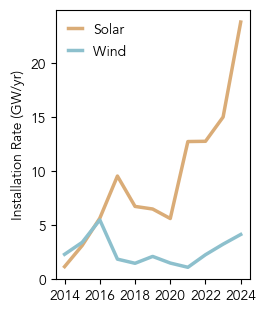

2014 9347.68909090909 2635.9309090909087


In [106]:
df_ = pd.read_excel(path_to_inputs + '/generators/2007-2025_national_capacity.xlsx', sheet_name = 0)  

df_solar_ = df_.loc[df_.Parameter.str.contains('Solar')].reset_index(drop = True)
df_wind_  = df_.loc[df_.Parameter.str.contains('Wind')].reset_index(drop = True)

period_ = df_solar_.columns.to_numpy()[1:]
period_ = np.array([int(period[:2] + period[-2:]) for period in period_])

df_solar_ = df_solar_.fillna(0.).sum(axis=0, numeric_only=True).to_numpy()
df_wind_  = df_wind_.fillna(0.).sum(axis=0, numeric_only=True).to_numpy()

period_        = period_[1:-1]
df_solar_rate_ = np.diff(df_solar_)[1:]#/df_solar_[1:-1]
df_wind_rate_  = np.diff(df_wind_)[1:]#/df_wind_[1:-1]
print(df_solar_)
print(df_wind_[1:-1].shape)
print(df_solar_[1:-1].shape)
print(period_[-1], df_solar_[-1], df_wind_[-1])
print(period_[-1], df_solar_rate_[-1], df_wind_rate_[-1])
print(period_)

print(period_[5:][0], df_solar_rate_[5:].mean(), df_wind_rate_[5:].mean())

In [87]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')
print(df_['technology'].unique())

df_1_ = df_.loc[df_['technology'] == 'Battery'].copy()
df_1_ = df_1_.loc[df_1_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']


df_1_ = df_1_.groupby(['period', 'scenario']).agg({'capacity_mw': 'sum',
                                               'capacity_mwh': 'sum'}).reset_index(drop = False)

df_1_['capacity_mw']  /= 1000.
df_1_['capacity_mwh'] /= 1000.
print(df_1_)

df_2_ = df_.loc[df_['technology'] == 'Solar'].copy()
df_2_ = df_2_.loc[df_2_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']
df_2_ = df_2_.groupby(['period', 
                       'scenario']).agg({'capacity_mw': 'sum',
                                         'capacity_mwh': 'sum'}).reset_index(drop = False)

df_2_['capacity_mw']  /= 1000.
df_2_['capacity_mwh'] /= 1000.
print(df_2_)

df_3_ = df_.loc[df_['technology'] == 'Wind'].copy()
df_3_ = df_3_.loc[df_3_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']
df_3_ = df_3_.groupby(['period', 
                       'scenario']).agg({'capacity_mw': 'sum',
                                         'capacity_mwh': 'sum'}).reset_index(drop = False)

df_3_['capacity_mw']  /= 1000.
df_3_['capacity_mwh'] /= 1000.
print(df_3_)

df_1_ = df_1_.set_index(["period"])
df_2_ = df_2_.set_index(["period"])
df_3_ = df_3_.set_index(["period"])

print(df_1_.loc[2030, 'capacity_mw']/38.6, df_1_.loc[2030, 'capacity_mwh']/201.5)
print(df_2_.loc[2030, 'capacity_mw'], df_3_.loc[2030, 'capacity_mw'])
print(df_2_.loc[2030, 'capacity_mw'] + df_3_.loc[2030, 'capacity_mw'])

print((df_2_.loc[2030, 'capacity_mw'] - df_2_.loc[2020, 'capacity_mw'])/10.)
print((df_3_.loc[2030, 'capacity_mw'] - df_3_.loc[2020, 'capacity_mw'])/10.)

['Battery' 'Coal' 'Gas' 'Hydro' 'Other' 'Solar' 'Wind' 'Hydrogen' 'Diesel'
 'Nuclear' 'Pumped Storage']
   period                          scenario  capacity_mw  capacity_mwh
0    2020  VRE & ESS (mid) Coal (low) - REF     0.000000      0.000000
1    2030  VRE & ESS (mid) Coal (low) - REF   153.981824    307.963648
2    2040  VRE & ESS (mid) Coal (low) - REF   400.820037    801.640073
3    2050  VRE & ESS (mid) Coal (low) - REF   650.111745   3231.283435
   period                          scenario  capacity_mw  capacity_mwh
0    2020  VRE & ESS (mid) Coal (low) - REF    33.963000           0.0
1    2030  VRE & ESS (mid) Coal (low) - REF   246.365854           0.0
2    2040  VRE & ESS (mid) Coal (low) - REF   995.165281           0.0
3    2050  VRE & ESS (mid) Coal (low) - REF  2138.928134           0.0
   period                          scenario  capacity_mw  capacity_mwh
0    2020  VRE & ESS (mid) Coal (low) - REF    37.715000           0.0
1    2030  VRE & ESS (mid) Coal (low) - REF 

## Cost-optimal deployment of renewable energy and battery storage in 2040 is three times the official targets in 2030

In [135]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_dispatch.csv')
print(df_['technology'].unique())
print(df_['scenario'].unique())

df_ = df_.groupby(['period', 
                   'technology', 
                   'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)

idx_ = ((df_['period'] == 2040) 
        & (df_['technology'] == 'Solar') 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))

df_1_ = df_.loc[idx_].reset_index(drop = True)
print(df_1_)


idx_ = ((df_['period'] == 2040) 
        & (df_['technology'] == 'Wind') 
        & (df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))

df_2_ = df_.loc[idx_].reset_index(drop = True)
print(df_2_)

idx_ = ((df_['technology'] == 'Battery') 
        & (df_['technology'] == 'Hydrogen')
        & (df_['technology'] == 'Transmission Losses'))

df_3_ = df_.loc[~idx_].reset_index(drop = True)

df_3_ = df_3_.groupby(['period', 
                       'scenario']).agg({'power_mw': 'sum'}).reset_index(drop = False)

idx_ = ((df_3_['period'] == 2040) 
        & (df_3_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'))

df_3_ = df_3_.loc[idx_].reset_index(drop = True)

df_1_ = df_1_.set_index(["period"])
df_2_ = df_2_.set_index(["period"])
df_3_ = df_3_.set_index(["period"])

print(100.*(df_1_.loc[2040, 'power_mw'] + df_2_.loc[2040, 'power_mw'])/df_3_.loc[2040, 'power_mw'])

['Coal' 'Gas' 'Hydro' 'Other' 'Solar' 'Wind' 'Hydrogen' 'Diesel' 'Battery'
 'Nuclear' 'Transmission Losses']
['VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
   period technology                                           scenario  \
0    2040      Solar  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...   

       power_mw  
0  1.655391e+09  
   period technology                                           scenario  \
0    2040       Wind  VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CA...   

       power_mw  
0  1.354283e+09  
70.05379490340727


In [108]:
df_ = pd.read_csv(path_to_tables + '/cost-grouped_capacity.csv')
print(df_['technology'].unique())

df_1_ = df_.loc[df_['technology'] == 'Battery'].copy()
df_1_ = df_1_.loc[df_1_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']


df_1_ = df_1_.groupby(['period', 'scenario']).agg({'capacity_mw': 'sum',
                                                   'capacity_mwh': 'sum'}).reset_index(drop = False)

df_1_['capacity_mw']  /= 1000.
df_1_['capacity_mwh'] /= 1000.
print(df_1_)

df_2_ = df_.loc[df_['technology'] == 'Solar'].copy()
df_2_ = df_2_.loc[df_2_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']
df_2_ = df_2_.groupby(['period', 
                       'scenario']).agg({'capacity_mw': 'sum',
                                         'capacity_mwh': 'sum'}).reset_index(drop = False)

df_2_['capacity_mw']  /= 1000.
df_2_['capacity_mwh'] /= 1000.
print(df_2_)

df_3_ = df_.loc[df_['technology'] == 'Wind'].copy()
df_3_ = df_3_.loc[df_3_['scenario'] == 'VRE & ESS (mid) Coal (low) - REF']
df_3_ = df_3_.groupby(['period', 
                       'scenario']).agg({'capacity_mw': 'sum',
                                         'capacity_mwh': 'sum'}).reset_index(drop = False)

df_3_['capacity_mw']  /= 1000.
df_3_['capacity_mwh'] /= 1000.
print(df_3_)

df_1_ = df_1_.set_index(["period"])
df_2_ = df_2_.set_index(["period"])
df_3_ = df_3_.set_index(["period"])

print(df_1_.loc[2040, 'capacity_mw'], df_1_.loc[2040, 'capacity_mwh'])
print(df_2_.loc[2040, 'capacity_mw'], df_3_.loc[2040, 'capacity_mw'])


['Battery' 'Coal' 'Gas' 'Hydro' 'Other' 'Solar' 'Wind' 'Hydrogen' 'Diesel'
 'Nuclear' 'Pumped Storage']
   period                          scenario  capacity_mw  capacity_mwh
0    2020  VRE & ESS (mid) Coal (low) - REF     0.000000      0.000000
1    2030  VRE & ESS (mid) Coal (low) - REF   153.981824    307.963648
2    2040  VRE & ESS (mid) Coal (low) - REF   400.820037    801.640073
3    2050  VRE & ESS (mid) Coal (low) - REF   650.111745   3231.283435
   period                          scenario  capacity_mw  capacity_mwh
0    2020  VRE & ESS (mid) Coal (low) - REF    33.963000           0.0
1    2030  VRE & ESS (mid) Coal (low) - REF   246.365854           0.0
2    2040  VRE & ESS (mid) Coal (low) - REF   995.165281           0.0
3    2050  VRE & ESS (mid) Coal (low) - REF  2138.928134           0.0
   period                          scenario  capacity_mw  capacity_mwh
0    2020  VRE & ESS (mid) Coal (low) - REF    37.715000           0.0
1    2030  VRE & ESS (mid) Coal (low) - REF 

In [148]:
df_ = pd.read_csv(path_to_tables + '/cost-emissions.csv')
print(df_['scenario'].unique())

df_1_ = df_.loc[df_['scenario'] == 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
df_2_ = df_.loc[df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
df_3_ = df_.loc[df_['scenario'] == 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']

df_1_ = df_1_.set_index(["period"])
df_2_ = df_2_.set_index(["period"])
df_3_ = df_3_.set_index(["period"])

print(1. - df_1_.loc[2040, 'carbon_emissions_tons']/df_1_.loc[2020, 'carbon_emissions_tons'])
print(1. - df_2_.loc[2040, 'carbon_emissions_tons']/df_2_.loc[2020, 'carbon_emissions_tons'])
print(1. - df_3_.loc[2040, 'carbon_emissions_tons']/df_3_.loc[2020, 'carbon_emissions_tons'])

['VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VRElow_STlow_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREhigh_SThigh_CONVhigh_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']
0.3203259955107193
0.20429005642099196
0.11869155511946294


In [147]:
df_ = pd.read_csv(path_to_tables + '/pier-emissions.csv')
print(df_['scenario'].unique())

df_1_ = df_.loc[df_['scenario'] == 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid']

df_ = pd.read_csv(path_to_tables + '/additional-emissions.csv')
print(df_['scenario'].unique())

df_2_ = df_.loc[df_['scenario'] == 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid']
# df_3_ = df_.loc[df_['scenario'] == 'VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid']

df_1_ = df_1_.set_index(["period"])
df_2_ = df_2_.set_index(["period"])
# df_3_ = df_3_.set_index(["period"])

print(1. - df_1_.loc[2040, 'carbon_emissions_tons']/df_1_.loc[2020, 'carbon_emissions_tons'])
print(1. - df_2_.loc[2040, 'carbon_emissions_tons']/df_2_.loc[2020, 'carbon_emissions_tons'])
# print(df_3_.loc[2040, 'carbon_emissions_tons']/df_3_.loc[2020, 'carbon_emissions_tons'])

['VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_80CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_100CAP_500GW_PIERmid']
['VREhigh_SThigh_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VRElow_STlow_CONVmid_H2_RES_8PRM_CC_50RPS_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAPLin_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_50RPS_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_8PRM_CC_90CAP_500GW_PIERmid'
 'VREmid_STmid_CONVmid_H2_RES_50RPS_90CAP_500GW_PIERmid']
0.20432838253828167
0.32148196960442676


## Climate policies or clean energy targets are essential in the long-term to meet ambitious carbon mitigation and net-zero goals

## Electricity demand projections are uncertain but solar-aligned demand can substantially reduce costs